# 🤖 LangGraph Examples - 1: A Hello World Agent

**Author:** *José Ignacio Orlando, PhD*

In this first example, we're going to learn how to structure a first execution graph in LangGraph, with no LLMs involved (yet). 

The idea is fairly simple: we're going to build a typical "Hello World" application using plain LangGraph that will randomly choose a greeting message for the user.

## Step 1 - Define the agent state

Regardless of whether we use a real LLM-based Agent or not, we're going to model this particular application as an execution graph in LangGraph. Hence, we need to establish the state of the agent.

The **state** is a shared data structure that retains context and information necessary for the entire application. Think of this as a little box where we save all the things we want the agent to be able to access while doing its job, or as a whiteboard in a meeting room, in which all the participants (the nodes) write and read information to stay updated and coordinate actions. It's kind of like "the memory" of the agent (but not exactly that).

To implement the agent state, we need to define a new class, `AgentState` (but you could call it differently if you want), that implements the class `TypedDict` from the package `typing`. Inside that class, we can model any "memory" that we want the agent to preserve. 

In this case, we only need the agent state to preserve user messages, so the structure is pretty simple:

In [1]:
# import the TypedDict class from typing
from typing import TypedDict

# define the AgentState class as an implementation of the TypedDict class
class AgentState(TypedDict):
    # add a single attribute: the message
    message : str


## Step 2 - Define a node

Once the state is defined, the next step is to define a **node**. Remember that nodes are individual functions/operations that perform tasks within the graph. These nodes are always defined in the same way: they receive an input (i.e., the current state of the graph), execute a series of operations, and return an output or an (updated) state. You can think of them as working stations in a factory: each station does its intended job, and only that, using always the same type of inputs and producing always the same type of output.

As nodes are modeled with functions, there aren't many constraints on what you could do inside them. BUT, there are a couple of things you **always need to remember**:
1. *It should receive an AgentState and output an AgentState.* Otherwise, the node will not have enough context for performing the task (i.e., it will not know your name), or the following executions of the agent will not know which effect the node had (i.e., because the state was not updated).
2. *It has to have a docstring explaining its behavior.* Docstrings are the only source of context for the LLMs to know what a particular node does. Although we're not using an LLM yet and the graph will be sequential, it's a good practice to get used to writing docstrings for the nodes.

Now, let's get into it. In this case, our node is intended to receive a state with a message (i.e., the name of the person who's interacting with the "Hello world" application), and concatenate a random greeting message from a set of predefined messages.

In [2]:
# import the random package so that we can randomly choose the message
from random import random

# define the node: receives the AgentState as input and outputs a new AgentState
def greeting_node(state: AgentState) -> AgentState:
    """Node that adds a random greeting message to the state"""

    # flip a (weird) coin XD
    r = random()
    # choose a random greeting message that uses the previous state
    if r < 0.25:
        random_message = "Hi " + state["message"] + " how is it going?"
    elif r < 0.5:
        random_message = "Hello hello " + state["message"] + "! How is your day going?"
    elif r < 0.75:
        random_message = "Greetings " + state["message"] + ". A pleasure to be here"
    else:
        random_message = "Hello " + state["message"] + "!"
    # update the message in the state with the new random message
    state["message"] = random_message

    # return the new state
    return state

## Step 3 - Define the execution graph

The last thing we need to define is the execution graph. In LangGraph, all applications are modeled with graphs (that's why it's called that way), and that makes total sense, because graphs have always been used to represent workflows, sequences of operations, conditional paths between different types of operations, etc.

Defining graphs in LangGraph is fairly simple: we need to define which type of graph we want to use (in this case, a `StateGraph`), and then add nodes and edges to it.

To add nodes, we use the method `add_node()` from the `StateGraph` class. This method requires us to set a (representative) name for the node, and indicate the function that is associated with it, both as input parameters of the method.

Apart from these nodes that we define as in Step 2, there are other pre-defined nodes that we have to remember to add: **START** and **END**. START marks the beginning of the execution graph, while END is the finish point. They can be defined either explicitly (i.e., by adding them using the `add_node()` method of the graph, and then connecting them with edges) or implicitly (i.e., by indicating which node is the first to execute after/before starting/finishing, respectively; this is equivalent to defining that there's an edge connecting START to the node, and the node to END). Below we're going to use the implicit way, but you'll find the explicit one in some other examples.

After defining all nodes, you need to establish the edges between them. In this case, we're not going to add other edges than the entry point and finish point with START and END.

Finally, we need to compile the graph using the `compile()` method. If we don't do this, LangGraph will not orchestrate the graph and leave it ready for execution.

In [3]:
# import the StateGraph class from LangGraph
from langgraph.graph import StateGraph

# initialize the StateGraph passing the AgentState
graph = StateGraph(AgentState)

# add nodes: in this case, just the greeting node
graph.add_node("greeter", greeting_node)
# as our graph will only have this execution node, we mark it as the first to
# execute after start, and the last to execute before end
graph.set_entry_point("greeter")
graph.set_finish_point("greeter")

# last step is to compile the graph to get the application ready for execution
app = graph.compile()

LangGraph provides us with a nice tool to illustrate the execution graph, based on Mermaid code. To use it, we need to retrieve the graph from the `app` that we created, and use the method `draw_mermaid_png()`, which we can display using the `display` function from `IPython.display`:

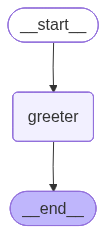

In [4]:
from IPython.display import Image, display

# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(app.get_graph().draw_mermaid_png()))

Notice that the implicit nodes START and END were already included in the execution graph, and that we see the exact sequence that we were looking for.

## Step 4 - Execution!

We're ready to execute the graph now! To do so, we will use the `invoke()` method of our `app` execution graph. The method requires us to input an `AgentState`, but instead of creating an instance of the class, since it inherits from `TypedDict`, we can use an explicit dictionary, and `typing` will do the rest:

In [5]:
name = "Nacho"
result = app.invoke({"message": name})
result["message"]

'Greetings Nacho. A pleasure to be here'

And that's it! If you run the previous code multiple times, you'll see different random responses. Is that an agent? Not at all! But at least you have all the building blocks you need to start preparing one. Well, not all of them, but some. In the next example, we're going to fill some missing spots :)